# Motivation

The goal of this project is to look at how Denmark’s public spending priorities have changed as the economy has grown.

Public spending is often talked about as one big number, but the welfare state is made up of many different areas, such as health, education, defence, social protection, and public administration. If we only look at total spending, we miss how the money is actually distributed between these areas.

I use COFOG data from Danmarks Statistik to look at the structure of public spending and how the main spending categories have changed over time. To connect this to the broader economy, I combine it with NAN1, which contains annual GDP data.

The final goal is to create a website that explains these changes visually for a non-technical reader. The website first guides the reader through the overall development and then lets them explore individual COFOG categories interactively.

# Dataset

This project uses two datasets from Danmarks Statistik:

1. COFOG  
   COFOG contains public expenditure divided by function. This allows us to study how government spending is distributed.

2. NAN1  
   NAN1 contains annual national accounts data, including GDP. This allows us to compare public spending with the overall size and growth of the Danish economy.

Together, these datasets make it possible to investigate how Denmark’s public spending priorities have changed over time and how these changes relate to economic growth.

In [172]:
import pandas as pd

nan1 = pd.read_excel("NAN1.xlsx", skiprows=2)
cofog = pd.read_excel("OFF29.xlsx", skiprows=2)

# Why these datasets?

COFOG was chosen because it directly describes what public money is spent on. Instead of only showing total public spending.

NAN1 was chosen because it provides annual GDP data. Since the project looks at public spending in relation to economic growth, GDP gives the broader economic context needed for comparison.

Together, COFOG and NAN1 make it possible to ask whether public spending simply grew with the economy, or whether the composition of spending changed over time.

# Goal for the end-user experience

The goal of the website is to make Danish public spending easier to understand for someone who is not used to working with economic data. I want the reader to get a clear idea of which parts of government spending have grown the most over the last 30 years, and how this relates to the growth of the economy.

The website should first guide the reader through the main story: how GDP and public spending developed, how spending is divided across COFOG categories, and which categories changed the most. After that, the reader should be able to explore the categories themselves through the interactive chart.

So the website should work both as a guided data story and as a small tool for exploring what is inside the public budget.

# Basic statistics

Before creating the final visualizations, we explored the structure of the datasets. This included checking the number of rows and columns, the time range, missing values, available categories, and the distribution of spending across years and categories.

In [173]:
cofog_wide = pd.read_excel("OFF29.xlsx", header=2)

# Rename first column to year
cofog_wide = cofog_wide.rename(columns={cofog_wide.columns[0]: "year"})
cofog_wide["year"] = cofog_wide["year"].astype(int)

cofog_wide.head()

,year,1. Generelle offentlige tjenester,"1.1. Udøvende og lovgivende organer, skatte- og finansvæsen, udenrigstjenesten",1.2. Økonomisk bistand til udlandet,1.3. Generelle tjenester,1.4. Grundforskning,1.5. F&U inden for generelle offentlige tjenester,1.6. Generelle offentlige tjenester i.a.n.,1.7. Transaktioner i forb. med offentlig gæld,1.8. Overførsler af generel art,...,10. Social beskyttelse,10.1. Sygdom og invaliditet,10.2. Alderdom,10.3. Efterlevende,10.4. Familie og børn,10.5. Arbejdsløshed,10.6. Bolig,10.7. Sociale ydelser i.a.n.,10.8. F&U inden for social beskyttelse,10.9. Social beskyttelse i.a.n.
0,1995,114317,15232,13352,3624,8438,505,10432,62735,0,...,260804,46450,71349,192,47331,62900,7850,18735,130,5868
1,1996,117684,16113,14291,3834,9122,440,10783,63100,0,...,270382,48863,74559,188,53843,59513,7960,19028,151,6277
2,1997,116136,17834,13909,3195,9369,554,11662,59614,0,...,273377,50826,76248,187,55741,56461,8193,18952,179,6588
3,1998,115514,19844,15049,3746,9301,737,11160,55679,0,...,278657,52878,78881,181,59032,54076,8475,17986,227,6921
4,1999,115032,20265,14850,3956,10272,737,11920,53031,0,...,283711,53803,78005,172,62542,54644,8659,18461,194,7231


In [174]:
cofog = cofog_wide.melt(
    id_vars="year",
    var_name="category",
    value_name="spending_million_dkk"
)

cofog["spending_million_dkk"] = pd.to_numeric(
    cofog["spending_million_dkk"],
    errors="coerce"
)

cofog.head()

,year,category,spending_million_dkk
0,1995,1. Generelle offentlige tjenester,114317
1,1996,1. Generelle offentlige tjenester,117684
2,1997,1. Generelle offentlige tjenester,116136
3,1998,1. Generelle offentlige tjenester,115514
4,1999,1. Generelle offentlige tjenester,115032


## Basic plots

The following plots were used to understand the datasets and decide which visualizations were most relevant for the final website:

1. Indexed GDP and public spending growth  
2. Public spending by COFOG category  
3. Change in spending share by category from 1995 to 2025  
4. Health spending as a share of GDP  
5. Interactive COFOG category explorer showing subcategories inside each main category

# Data cleaning and preprocessing

The data from Danmarks Statistik was already structured, but preprocessing was necessary to make the two datasets comparable.

The main preprocessing steps were:

1. Renaming columns for readability
2. Converting year values to a common format
3. Converting spending and GDP values to numeric values
4. Filtering COFOG to the relevant main categories
5. Merging the two datasets by year

In [175]:
# Shape of datasets
print("COFOG shape:", cofog.shape)
print("NAN1 shape:", nan1.shape)

COFOG shape: (2356, 3)
NAN1 shape: (31, 3)


In [176]:
import matplotlib.pyplot as plt
# Load NAN1 GDP data
nan1 = pd.read_excel("NAN1.xlsx", header=2)

nan1 = nan1.rename(columns={
    nan1.columns[0]: "transaction",
    nan1.columns[1]: "year",
    nan1.columns[2]: "gdp_billion_dkk"
})

nan1["transaction"] = nan1["transaction"].ffill()
nan1["year"] = nan1["year"].astype(int)
nan1["gdp_billion_dkk"] = pd.to_numeric(nan1["gdp_billion_dkk"], errors="coerce")

# Convert GDP from billion DKK to million DKK, because OFF29 uses million DKK
nan1["gdp_million_dkk"] = nan1["gdp_billion_dkk"] * 1000


# Load COFOG/OFF29 data
cofog_wide = pd.read_excel("OFF29.xlsx", header=2)

cofog_wide = cofog_wide.rename(columns={
    cofog_wide.columns[0]: "year"
})

cofog_wide["year"] = cofog_wide["year"].astype(int)


# Convert COFOG from wide to long format
cofog = cofog_wide.melt(
    id_vars="year",
    var_name="category",
    value_name="spending_million_dkk"
)

cofog["spending_million_dkk"] = pd.to_numeric(
    cofog["spending_million_dkk"],
    errors="coerce"
)

In [177]:
main_categories = [
    "1. Generelle offentlige tjenester",
    "2. Forsvar",
    "3. Offentlig orden og sikkerhed",
    "4. Økonomiske anliggender",
    "5. Miljøbeskyttelse",
    "6. Boliger og offentlige faciliteter",
    "7. Sundhedsvæsen",
    "8. Fritid, kultur og religion",
    "9. Undervisning",
    "10. Social beskyttelse"
]

cofog_main = cofog[cofog["category"].isin(main_categories)].copy()

In [178]:
category_translation = {
    "1. Generelle offentlige tjenester": "General public services",
    "2. Forsvar": "Defence",
    "3. Offentlig orden og sikkerhed": "Public order and safety",
    "4. Økonomiske anliggender": "Economic affairs",
    "5. Miljøbeskyttelse": "Environmental protection",
    "6. Boliger og offentlige faciliteter": "Housing and community amenities",
    "7. Sundhedsvæsen": "Health",
    "8. Fritid, kultur og religion": "Recreation, culture and religion",
    "9. Undervisning": "Education",
    "10. Social beskyttelse": "Social protection"
}

cofog_main["category_en"] = cofog_main["category"].map(category_translation)

# Data analysis

The analysis is built around three main questions:

1. How did public spending develop compared to Denmark’s economic growth?
2. Which COFOG categories became larger or smaller parts of total public spending?
3. What is actually inside the main COFOG categories when we look at the subcategories?

To answer these questions, I calculated indexed growth for GDP and total public spending, each COFOG category’s share of total spending, and the change in category shares from 1995 to 2025.

I also chose to look more closely at health spending as a share of GDP, because health is one of the central welfare-state categories and it stood out in the category-change chart.

Finally, I used the COFOG subcategories for the interactive explorer. This makes it possible to move from the big overview into the details of one category at a time, instead of showing all subcategories at once.

# Use of AI tools

This project does not use machine learning as part of the actual data analysis. I did not train a predictive model, and the results are based on descriptive statistics, visualizations, and comparisons over time.

I did use AI tools during the process as support. This was mainly for brainstorming the project structure, improving wording, generating and debugging code examples, and turning the assignment requirements into a clearer notebook and website structure.

The final decisions about the research question, datasets, visualizations, interpretation, and written conclusions were made by me. I also checked the analysis against the actual COFOG and NAN1 data, and any AI-generated code or text was edited and adapted before being included in the final project.

So AI was used as a workflow assistant, not as a method for producing the results.

# Genre

The website uses a Martini Glass Structure, as described by Segel and Heer.

I chose this structure because the reader needs some guidance before the data becomes meaningful. COFOG categories are not something most people immediately understand, so the website first explains the main story step by step.

The guided part starts with the main research question and then moves through the key visualizations: indexed GDP and public spending growth, the distribution of spending across COFOG categories, the biggest changes in spending shares from 1995 to 2025, and health spending as a share of GDP.

After that, the website becomes more exploratory. The interactive COFOG explorer lets the reader choose a main spending category and look inside its subcategories. This way, the reader first gets the overall story and can then explore the details themselves.

# Visual narrative and narrative structure

Following Segel and Heer, the website is built as a guided story that gradually opens up for exploration.

For the **visual narrative**, the website moves from broad context to more detail. It starts with indexed GDP and public spending growth, then shows how public spending is divided across COFOG categories, and finally lets the reader explore subcategories. Important changes are made clearer through focused charts, especially the category change chart and the health case study.

For the **narrative structure**, the website uses ordering, short explanations, and interactivity. The charts are shown in a sequence where each one leads naturally to the next: first the economic context, then the spending structure, then the biggest changes, and finally the interactive explorer. The interactive COFOG chart gives the reader control at the end, after they have already been introduced to the overall story.

# Visualizations

The website contains five main visualizations, each chosen for a specific purpose. Together, they move from the broad economic context to the internal structure of public spending: comparing public spending with GDP growth, showing how spending is distributed across COFOG categories, highlighting the largest changes from 1995 to 2025, and finally allowing the reader to explore the subcategories inside each main spending area.

In [179]:
# Total spending per year
total_spending = (
    cofog_main
    .groupby("year", as_index=False)["spending_million_dkk"]
    .sum()
    .rename(columns={"spending_million_dkk": "total_spending_million_dkk"})
)

# Add total spending to category data
cofog_main = cofog_main.merge(total_spending, on="year", how="left")

# Category share of total public spending
cofog_main["category_share"] = (
    cofog_main["spending_million_dkk"] / cofog_main["total_spending_million_dkk"]
)

# Merge with GDP
merged = cofog_main.merge(
    nan1[["year", "gdp_million_dkk"]],
    on="year",
    how="inner"
)

# Spending as share of GDP
merged["spending_share_of_gdp"] = (
    merged["spending_million_dkk"] / merged["gdp_million_dkk"]
)

merged["total_spending_share_of_gdp"] = (
    merged["total_spending_million_dkk"] / merged["gdp_million_dkk"]
)

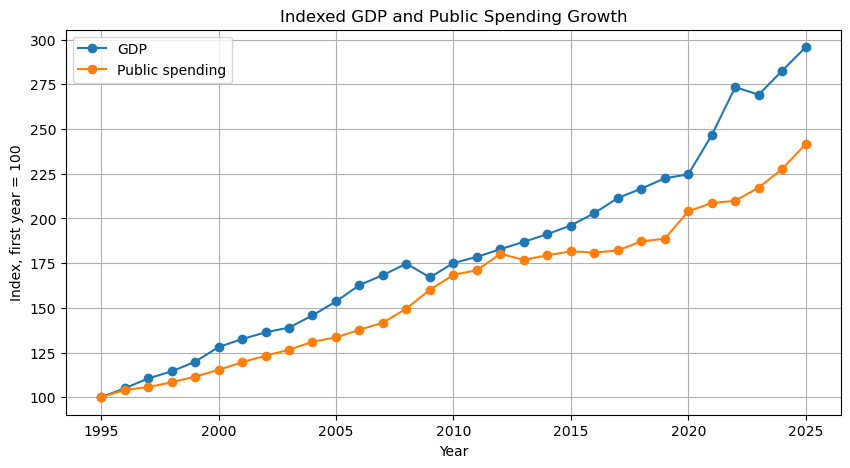

In [180]:
indexed = total_spending.merge(
    nan1[["year", "gdp_million_dkk"]],
    on="year",
    how="inner"
).sort_values("year")

indexed["gdp_index"] = indexed["gdp_million_dkk"] / indexed["gdp_million_dkk"].iloc[0] * 100
indexed["spending_index"] = indexed["total_spending_million_dkk"] / indexed["total_spending_million_dkk"].iloc[0] * 100

plt.figure(figsize=(10, 5))

plt.plot(indexed["year"], indexed["gdp_index"], marker="o", label="GDP")
plt.plot(indexed["year"], indexed["spending_index"], marker="o", label="Public spending")

plt.title("Indexed GDP and Public Spending Growth")
plt.xlabel("Year")
plt.ylabel("Index, first year = 100")
plt.legend()
plt.grid(True)
plt.show()

## Indexed GDP and public spending growth

This chart compares GDP and total public spending by indexing both series to 100 in 1995. This makes the two trends comparable even though GDP and public spending have different absolute sizes.

The chart shows whether public spending grew faster or slower than the economy over the period. This is important because raw spending numbers alone can be misleading: public spending may increase simply because the economy and price level increase. Indexing makes the comparison more about relative growth.

**COFOG category shares over time**

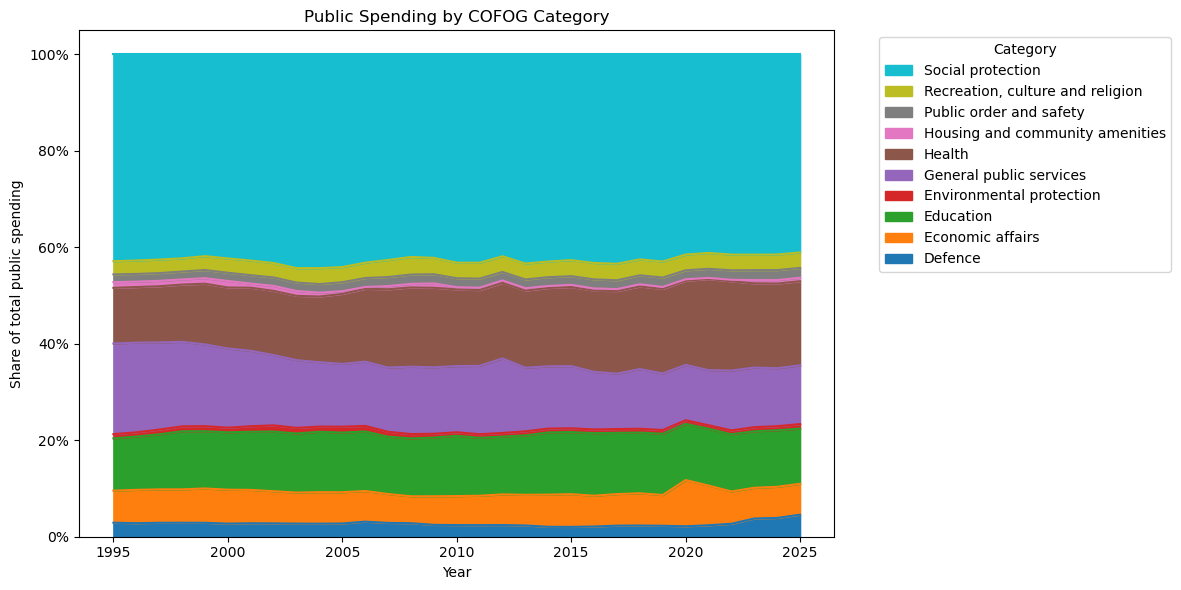

In [181]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

category_share_wide = cofog_main.pivot(
    index="year",
    columns="category_en",
    values="category_share"
)

ax = category_share_wide.plot(
    kind="area",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Public Spending by COFOG Category")
plt.xlabel("Year")
plt.ylabel("Share of total public spending")

# Change y-axis from 0–1 to 0–100%
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Reverse legend order to match the visual stack from top to bottom
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    title="Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("spending_by_category_percent.png", dpi=300, bbox_inches="tight")
plt.show()

## Public spending by COFOG category

This visualization shows how total public spending is distributed across the ten main COFOG categories over time. It gives an overview of the structure of Danish public spending and makes it possible to see which areas dominate the public budget.

The chart shows that social protection is the largest spending area, followed by major welfare-state categories such as health and education. 

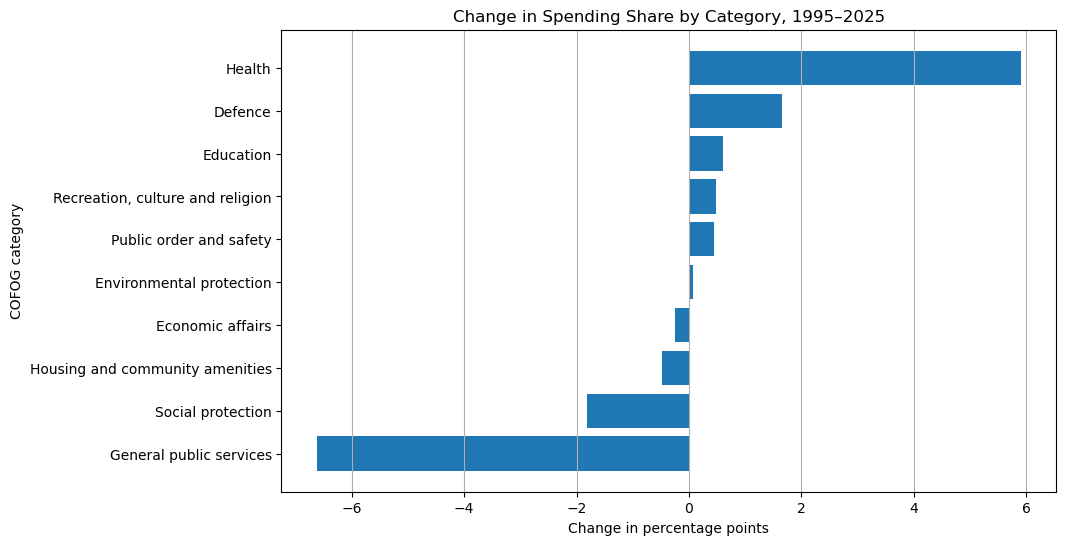

In [182]:
first_year = cofog_main["year"].min()
last_year = cofog_main["year"].max()

first = cofog_main[cofog_main["year"] == first_year][
    ["category", "category_en", "category_share"]
]

last = cofog_main[cofog_main["year"] == last_year][
    ["category", "category_share"]
]

category_change = first.merge(
    last,
    on="category",
    suffixes=("_first", "_last")
)

category_change["change_percentage_points"] = (
    category_change["category_share_last"] - category_change["category_share_first"]
) * 100

category_change = category_change.sort_values("change_percentage_points")

plt.figure(figsize=(10, 6))

plt.barh(
    category_change["category_en"],
    category_change["change_percentage_points"]
)

plt.title(f"Change in Spending Share by Category, {first_year}–{last_year}")
plt.xlabel("Change in percentage points")
plt.ylabel("COFOG category")
plt.grid(axis="x")
plt.show()

## Change in spending share by category, 1995–2025

The stacked COFOG chart gives a good overview, but it is still hard to see exactly which categories gained or lost importance. This bar chart makes that clearer by comparing each category’s share of total public spending in 1995 and 2025.

Positive values mean that a category became a larger part of the public budget. Negative values mean that it became a smaller part.

The biggest increases are in health and defence, while general public services and social protection decreased as shares of total spending. This shows that public spending priorities shifted over time, but the chart alone cannot explain why. To explain the causes, we would need extra data, for example on demographics, policy reforms, or political decisions.

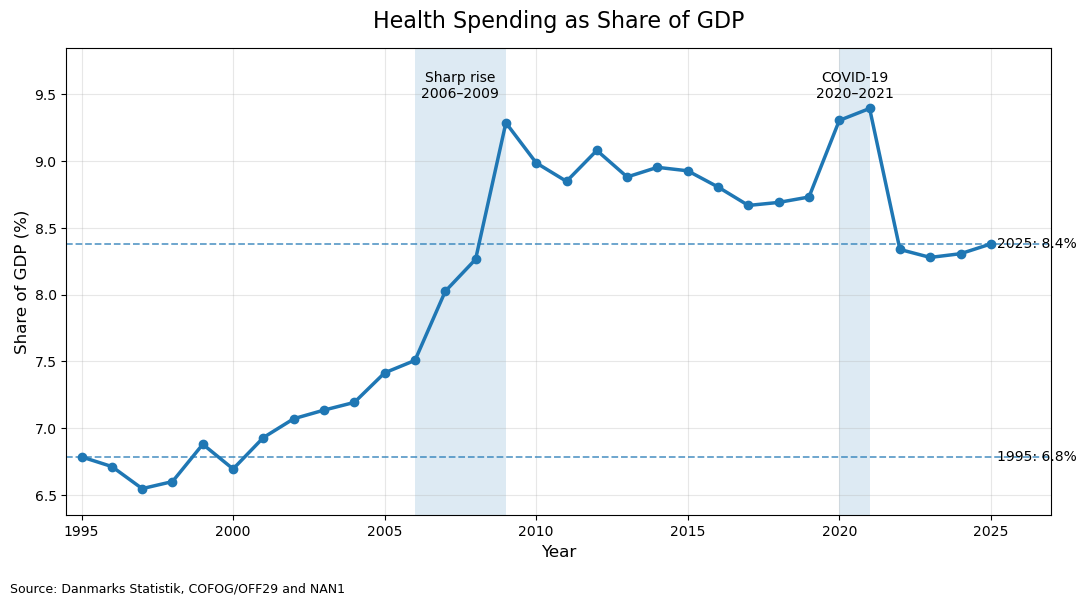

In [183]:
selected_category = "7. Sundhedsvæsen"
selected_category_en = category_translation[selected_category]

category_data = merged[merged["category"] == selected_category].sort_values("year").copy()
category_data["share_percent"] = category_data["spending_share_of_gdp"] * 100

first_year = category_data["year"].min()
last_year = category_data["year"].max()

first_value = category_data.loc[category_data["year"] == first_year, "share_percent"].iloc[0]
last_value = category_data.loc[category_data["year"] == last_year, "share_percent"].iloc[0]

plt.figure(figsize=(11, 5.8))

plt.plot(
    category_data["year"],
    category_data["share_percent"],
    marker="o",
    linewidth=2.5
)

# Reference lines for start and end levels
plt.axhline(first_value, linestyle="--", linewidth=1.3, alpha=0.7)
plt.axhline(last_value, linestyle="--", linewidth=1.3, alpha=0.7)

plt.text(
    last_year + 0.2,
    first_value,
    f"{first_year}: {first_value:.1f}%",
    va="center",
    fontsize=10
)

plt.text(
    last_year + 0.2,
    last_value,
    f"{last_year}: {last_value:.1f}%",
    va="center",
    fontsize=10
)

# Highlight sharp rise period
plt.axvspan(2006, 2009, alpha=0.15)
plt.text(
    2007.5,
    category_data["share_percent"].max() + 0.08,
    "Sharp rise\n2006–2009",
    ha="center",
    fontsize=10
)

# Highlight COVID period
plt.axvspan(2020, 2021, alpha=0.15)
plt.text(
    2020.5,
    category_data["share_percent"].max() + 0.08,
    "COVID-19\n2020–2021",
    ha="center",
    fontsize=10
)

plt.title("Health Spending as Share of GDP", fontsize=16, pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Share of GDP (%)", fontsize=12)

plt.xlim(first_year - 0.5, last_year + 2)
plt.ylim(
    category_data["share_percent"].min() - 0.2,
    category_data["share_percent"].max() + 0.45
)

plt.grid(True, alpha=0.3)

plt.figtext(
    0.01,
    -0.03,
    "Source: Danmarks Statistik, COFOG/OFF29 and NAN1",
    ha="left",
    fontsize=9
)

plt.tight_layout()
plt.savefig("health_spending_share_gdp_polished.png", dpi=300, bbox_inches="tight")
plt.show()

## Health spending as share of GDP

Health was chosen as a focused case study because it is one of the central areas of the Danish welfare state and one of the easiest categories for a general reader to understand.

By showing health spending as a share of GDP, the chart connects one specific welfare area to the size of the overall economy. This makes it possible to see whether health spending became larger or smaller relative to Denmark’s economic capacity, instead of only looking at raw spending.

The sharp increase in healthcare expenditure from 2006 to 2009 should be interpreted carefully. A major part of the explanation is the 2007 structural reform, where Denmark replaced the counties with five regions and reorganized healthcare responsibilities and financing. This likely affected how healthcare spending appears in the public accounts. At the same time, healthcare was also a politically prioritized area, with rising hospital activity, treatment capacity, and investment in areas such as cancer treatment and specialized care.

The increase in healthcare expenditure in 2020 is mainly explained by the COVID-19 pandemic. Denmark had to expand testing, tracing, protective equipment, hospital preparedness, and emergency healthcare capacity. This created a temporary rise in public health spending.

In [184]:
import pandas as pd
import json
import re
from pathlib import Path

In [185]:
main_categories = [
    "1. Generelle offentlige tjenester",
    "2. Forsvar",
    "3. Offentlig orden og sikkerhed",
    "4. Økonomiske anliggender",
    "5. Miljøbeskyttelse",
    "6. Boliger og offentlige faciliteter",
    "7. Sundhedsvæsen",
    "8. Fritid, kultur og religion",
    "9. Undervisning",
    "10. Social beskyttelse"
]

def get_category_code(category):
    """
    Extracts the COFOG code from a category string.
    Example:
    '7. Sundhedsvæsen' -> '7'
    '7.3. Hospitalstjenester' -> '7.3'
    """
    match = re.match(r"^(\d+(?:\.\d+)?)\.", str(category))
    return match.group(1) if match else None

def get_parent_code(category):
    """
    Gets the main parent category.
    Example:
    '7.3. Hospitalstjenester' -> '7'
    """
    code = get_category_code(category)
    return code.split(".")[0] if code else None

cofog["code"] = cofog["category"].apply(get_category_code)
cofog["parent_code"] = cofog["category"].apply(get_parent_code)
cofog["is_main_category"] = cofog["category"].isin(main_categories)

#cofog.head()

In [186]:
# Main categories only
cofog_main = cofog[cofog["is_main_category"]].copy()

# Add English names for display
cofog_main["category_en"] = cofog_main["category"].map(category_translation)

# Subcategories only
cofog_sub = cofog[~cofog["is_main_category"]].copy()

# Latest year for overview bar chart
latest_year = cofog["year"].max()

overview_data = cofog_main[cofog_main["year"] == latest_year].copy()
overview_data = overview_data.sort_values("spending_million_dkk", ascending=True)

#overview_data[["category_en", "spending_million_dkk"]].head()

In [187]:
subcategory_translation = {
    # General public services
    "1.1. Udøvende og lovgivende organer, skatte- og finansvæsen, udenrigstjenesten": "Executive/legislative bodies, finance and foreign affairs",
    "1.2. Økonomisk bistand til udlandet": "Foreign economic aid",
    "1.3. Generelle tjenester": "General services",
    "1.4. Grundforskning": "Basic research",
    "1.5. F&U inden for generelle offentlige tjenester": "R&D: general public services",
    "1.6. Generelle offentlige tjenester i.a.n.": "Other general public services",
    "1.7. Transaktioner i forb. med offentlig gæld": "Public debt transactions",
    "1.8. Overførsler af generel art": "General transfers",

    # Defence
    "2.1. Militært forsvar": "Military defence",
    "2.2. Civilforsvar": "Civil defence",
    "2.3. Militærhjælp til udlandet": "Foreign military aid",
    "2.4. F&U inden for forsvar": "R&D: defence",
    "2.5. Forsvar i.a.n.": "Other defence",

    # Public order and safety
    "3.1. Politi": "Police",
    "3.2. Brandvæsen": "Fire services",
    "3.3. Domstole": "Courts",
    "3.4. Fængsler": "Prisons",
    "3.5. F&U inden for offentlig orden og sikkerhed": "R&D: public order and safety",
    "3.6. Offentlig orden og sikkerhed i.a.n.": "Other public order and safety",

    # Economic affairs
    "4.1. Generelle anliggender inden for økonomi, handel og arbejdsmarked": "General economic, trade and labour affairs",
    "4.2. Landbrug, skovbrug, fiskeri og jagt": "Agriculture, forestry, fishing and hunting",
    "4.3. Brændstof og energi": "Fuel and energy",
    "4.4. Råstofudvinding, fremstillingsvirksomhed og bygge- og anlægsvirksomhed": "Mining, manufacturing and construction",
    "4.5. Transport": "Transport",
    "4.6. Kommunikation": "Communication",
    "4.7. Andre Erhverv": "Other industries",
    "4.8. F&U i emner inden for økonomiske anliggende": "R&D: economic affairs",
    "4.9. Økonomiske anliggender i.a.n.": "Other economic affairs",

    # Environmental protection
    "5.1. Affaldshåndtering": "Waste management",
    "5.2. Spildevandshåndtering": "Wastewater management",
    "5.3. Forureningsbekæmpelse": "Pollution abatement",
    "5.4. Beskyttelse af biodiversitet og landskab": "Biodiversity and landscape protection",
    "5.5. F&U inden for miljøbeskyttelse": "R&D: environmental protection",
    "5.6. Miljøbeskyttelse i.a.n": "Other environmental protection",

    # Housing and community amenities
    "6.1. Boligbyggeri": "Housing development",
    "6.2. By- og egnsudvikling": "Community development",
    "6.3. Vandforsyning": "Water supply",
    "6.4. Gadebelysning": "Street lighting",
    "6.5. F&U inden for boliger og offentlige faciliteter": "R&D: housing and community amenities",
    "6.6. Boliger og offentlige faciliteter i.a.n.": "Other housing and community amenities",

    # Health
    "7.1. Medicinske produkter, apparater og udstyr": "Medical products, appliances and equipment",
    "7.2. Ambulant behandling": "Ambulance services",
    "7.3. Hospitalstjenester": "Hospital services",
    "7.4. Offentligt sundhedsvæsen": "Public health services",
    "7.5. F &U inden for sundhedsvæsen": "R&D: health",
    "7.6. Sundhedsvæsen i.a.n.": "Other health",

    # Recreation, culture and religion
    "8.1. Fritids- og sportstjenester": "Recreational and sporting services",
    "8.2. Kulturtjenester": "Cultural services",
    "8.3. Radio & TV-udsendelser samt forlagsvirksomhed": "Broadcasting and publishing",
    "8.4. Religiøse og andre organisationer": "Religious and other community services",
    "8.5. F&U inden for fritid, kultur og religion": "R&D: recreation, culture and religion",
    "8.6. Fritid, kultur og religion i.a.n.": "Other recreation, culture and religion",

    # Education
    "9.1. Folkeskolen og lign.": "Primary and lower secondary education",
    "9.2. Ungdomsuddannelsesniveau": "Upper secondary education",
    "9.3. Højere og videregående uddannelse": "Higher education",
    "9.4. Undervisning uden for niveauplacering": "Education not definable by level",
    "9.5. Undervisning i.a.n.": "Other education",

    # Social protection
    "10.1. Sygdom og invaliditet": "Sickness and disability",
    "10.2. Alderdom": "Old age",
    "10.3. Efterlevende": "Survivor benefits",
    "10.4. Familie og børn": "Family and children",
    "10.5. Arbejdsløshed": "Unemployment",
    "10.6. Bolig": "Housing",
    "10.7. Sociale ydelser i.a.n.": "Other social benefits",
    "10.8. F&U inden for social beskyttelse": "R&D: social protection",
    "10.9. Social beskyttelse i.a.n.": "Other social protection"
}

In [188]:
import plotly.graph_objects as go

fig = go.Figure()

buttons = []
trace_indices_by_category = {}
trace_index = 0

# Choose default category using Danish raw name for filtering
default_category = "7. Sundhedsvæsen"
default_category_en = category_translation[default_category]

for main_cat in main_categories:
    parent_code = get_parent_code(main_cat)
    main_cat_en = category_translation[main_cat]

    data = cofog_sub[cofog_sub["parent_code"] == parent_code].copy()
    data = data.sort_values(["category", "year"])

    indices = []

    for subcat in data["category"].unique():
        subcat_data = data[data["category"] == subcat].sort_values("year")

        # English display name for subcategory
        subcat_en = subcategory_translation.get(subcat, subcat)

        fig.add_trace(go.Scatter(
            x=subcat_data["year"],
            y=subcat_data["spending_million_dkk"] / 1000,
            mode="lines+markers",
            name=subcat_en,
            visible=(main_cat == default_category),
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "Year: %{x}<br>"
                "Spending: %{y:.2f} billion DKK"
                "<extra></extra>"
            )
        ))

        indices.append(trace_index)
        trace_index += 1

    trace_indices_by_category[main_cat] = indices

total_traces = len(fig.data)

for main_cat in main_categories:
    main_cat_en = category_translation[main_cat]
    visible = [False] * total_traces

    for idx in trace_indices_by_category[main_cat]:
        visible[idx] = True

    buttons.append(dict(
        label=main_cat_en,
        method="update",
        args=[
            {"visible": visible},
            {
                "title": {
                    "text": f"{main_cat_en}",
                    "x": 0.5,
                    "xanchor": "center"
                },
                "yaxis": {"title": "Spending, billion DKK"},
                "xaxis": {"title": "Year"}
            }
        ]
    ))

fig.update_layout(
    title=dict(
        text=f"{default_category_en}",
        x=0.5,
        xanchor="center"
    ),
    xaxis_title="Year",
    yaxis_title="Spending, billion DKK",
    height=650,
    hovermode="x unified",
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=0,
            y=1.15,
            showactive=True
        )
    ],
    legend=dict(
        orientation="h",
        y=-0.25
    )
)

html_snippet = fig.to_html(
    full_html=False,
    include_plotlyjs="cdn",
    div_id="cofog-dropdown-chart"
)

from IPython.display import HTML, display
display(HTML(html_snippet))

## Interactive COFOG category explorer

This chart lets the reader choose one of the ten main COFOG categories and see the subcategories inside it. The purpose is to avoid showing all subcategories at once, which would make the visualization too crowded. Instead, the reader can focus on one spending area at a time.

For example, selecting **Health** shows how health spending is divided between hospital services, outpatient treatment, medical products, public health, and other health-related areas. Selecting **Social protection** opens a different structure, including spending related to old age, unemployment, sickness and disability, family support, and housing.

The chart is meant as the exploratory part of the project. After the main story has shown how public spending changed overall, this visualization lets the reader investigate what is hidden inside each major spending category.

# Discussion

## What went well?

Using COFOG and NAN1 together worked well because they answered different parts of the project question. COFOG made it possible to look at what public money is spent on, while NAN1 gave the economic context through GDP.

The visualizations also ended up supporting each other well. The indexed GDP and public spending chart gave the broad economic background, while the COFOG charts showed how public spending is structured. The category change chart made it easier to see which areas changed the most, and the health chart gave a more focused example of one important welfare-state category.

The interactive COFOG explorer was useful because it let the reader go beyond the guided story and look inside each main spending area. This helped avoid showing too much data at once, while still making the website more exploratory.

## What is still missing?

There are still some limitations. Spending data can show that priorities changed, but it cannot fully explain why they changed. Political decisions, demographic changes, reforms, and crises may all affect public spending, but they are not directly included in this analysis.

Another limitation is that COFOG categories are still quite broad. The interactive explorer includes subcategories, but even those do not show every detailed policy decision or institutional change behind the numbers.

The project also mainly uses current-price spending. This works when comparing spending with current-price GDP, but raw spending growth should not be understood as pure real growth, because prices also change over time.

## What could be improved?

The project could be improved by adding more context, such as population age structure, unemployment, inflation-adjusted spending, or election periods. That would make it easier to explain why some categories became larger or smaller over time.

Future versions could also include more annotations for important events, such as major policy reforms. It could also be interesting to compare Denmark with other Nordic countries to see whether the same patterns appear elsewhere.

# References

Danmarks Statistik. COFOG data on public expenditure by function. Statistikbanken.

Danmarks Statistik. NAN1 national accounts data. Statistikbanken.

Segel, E., & Heer, J. Narrative Visualization: Telling Stories with Data.

# Contributions

This project was completed individually. I was responsible for data collection, preprocessing, exploratory analysis, visualization design, website implementation, notebook writing, and final interpretation.

[View the webpage notebook](index.html)